# Concept Hotspot Map — Feed-Forward Layer Activation Differences

Loads two concept groups from MongoDB, aggregates activations across all scans,
and plots the **mean difference map** and **t-statistic significance map** for
feed-forward layers only.

**How to read the output:**
- **Red** → neurons that fire consistently *higher* for group A
- **Blue** → neurons that fire consistently *higher* for group B
- **Grey / masked** → not statistically significant at the chosen threshold

## Cell 1 — Imports

In [38]:
import sys, os, re

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from neuralsignal.backend.ns_backend import NSBackend
from neuralsignal.core.modules.neuralsignal_config import sdk_config

print("Imports OK")

Imports OK


## Cell 2 — Config

- `LAYER_NAME_FILTER`: substring matched against layer names to select layer type.
  For flan-t5-large feed-forward layers use `"DenseReluDense"`.
  Use `"SelfAttention.o"` for attention output layers, or `"all"` for everything.
- `N_SCANS`: scans per group. More = cleaner signal (200+ recommended).
- `T_THRESHOLD`: |t| below this is masked in the significance map (~2.0 ≈ p<0.05).
- `TOP_K`: hotspot coordinates to print.

In [39]:
APPLICATION_NAME     = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

GROUND_TRUTH_A = "0"
GROUND_TRUTH_B = "1"
LABEL_A        = "Concept A (gt=0)"
LABEL_B        = "Concept B (gt=1)"

# Substring matched against layer names. Run Cell 4 to see all available types.
LAYER_NAME_FILTER = "DenseReluDense.act"

N_SCANS        = 100
ZONE_AGGREGATE = 1    # average N consecutive zones together (1 = no aggregation)
                      # check zone_size printed by Cell 5 before increasing
T_THRESHOLD    = 2.0
TOP_K          = 20

## Cell 3 — Connect to backend & load scans

In [40]:
import tempfile

backend_cfg = sdk_config.get_backend_config()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)


def load_group(ground_truth_value, n):
    query = {"ground_truth": ground_truth_value}
    scans = []
    for doc in be.query(query).limit(n):
        try:
            scans.append(be.deserialize_scan(doc))
        except Exception as e:
            print(f"  skipping {doc.get('_id')}: {e}")
    return scans


print(f"Loading {LABEL_A} ...")
scans_a = load_group(GROUND_TRUTH_A, N_SCANS)
print(f"  loaded {len(scans_a)} scans")

print(f"Loading {LABEL_B} ...")
scans_b = load_group(GROUND_TRUTH_B, N_SCANS)
print(f"  loaded {len(scans_b)} scans")

Loading Concept A (gt=0) ...
  loaded 100 scans
Loading Concept B (gt=1) ...
  loaded 100 scans


## Cell 4 — Discover feed-forward layers

Inspects the first scan to find all layers whose name contains `LAYER_NAME_FILTER`,
in forward-pass order. These layer IDs are used for all subsequent extraction.

In [48]:
def get_filtered_layers(scan, name_filter):
    """Return [(layer_id, full_name, short_label), ...] matching name_filter."""
    lid_to_name = scan.get("layer_id_to_name", {})

    # If layer_id_to_name is missing, fall back to using layer IDs as names
    if not lid_to_name:
        lid_to_name = {lid: str(lid) for lid in scan["layer_order"]}

    rows = []
    for i, lid in enumerate(scan["layer_order"]):
        name = lid_to_name.get(lid, str(lid))
        if name_filter != "all" and name_filter not in name:
            continue
        m = re.search(r'\.([0-9]+)\.', name)
        block_idx = m.group(1) if m else str(i)
        side = "enc" if "encoder" in name.lower() else "dec"
        short = f"{side}.{block_idx}"
        rows.append((lid, name, short))
    return rows


first_scan     = scans_a[0]
lid_to_name    = first_scan.get("layer_id_to_name", {})
if not lid_to_name:
    lid_to_name = {lid: str(lid) for lid in first_scan["layer_order"]}

all_names = [lid_to_name.get(lid, str(lid)) for lid in first_scan["layer_order"]]
unique_types = sorted(set(
    name.split(".")[-1] for name in all_names
))
print(f"Total captured layers: {len(all_names)}")
print(f"Unique layer types (last segment of name):")
for t in unique_types:
    count = sum(1 for n in all_names if n.endswith(t))
    print(f"  {count:>4}x  {t}")

ff_layers = get_filtered_layers(first_scan, LAYER_NAME_FILTER)
print(f"\nMatched {len(ff_layers)} layers for filter '{LAYER_NAME_FILTER}'")
if not ff_layers:
    print("  -> No match! Check the layer types above and update LAYER_NAME_FILTER.")
else:
    for lid, name, label in ff_layers:
        print(f"  {label:<12}  {name}")

# Diagnose actual tensor shapes for matched layers
if ff_layers:
    print("\nTensor shapes for matched layers (first scan):")
    for lid, name, label in ff_layers[:6]:
        t = scans_a[0]["outputs"].get(lid)
        if t is None:
            print(f"  {label:<12}  NOT FOUND in outputs")
        elif hasattr(t, "shape"):
            print(f"  {label:<12}  shape={tuple(t.shape)}  dtype={t.dtype}")
        else:
            print(f"  {label:<12}  type={type(t)}")

Total captured layers: 553
Unique layer types (last segment of name):
    48x  act
    72x  k
    72x  layer_norm
   120x  o
     1x  output
    72x  q
    72x  v
    48x  wi_0
    48x  wi_1
    48x  wo

Matched 48 layers for filter 'DenseReluDense.act'
  enc.6         encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.15        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.24        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.33        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.42        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.51        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.60        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.69        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.78        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.87        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.96        encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.105       encoder.T5Block.T5LayerFF.DenseReluDense.act
  enc.114     

## Cell 5 — Build activation matrices

For each scan, extracts only the feed-forward layer activations and stacks them
into a `(n_scans, n_ff_layers, zone_size)` matrix per group.

In [49]:
FF_LAYER_IDS = [lid for lid, _, _ in ff_layers]
FF_LABELS    = [label for _, _, label in ff_layers]


def scan_to_ff_heatmap(scan, layer_ids):
    """Return (n_ff_layers, zone_size) float32 array, or None on failure."""
    rows = []
    for lid in layer_ids:
        tensor = scan["outputs"].get(lid)
        if tensor is None:
            return None
        t = tensor.float().cpu()
        if t.dim() == 1:
            rows.append(t.numpy())
        elif t.dim() == 2:
            rows.append(t.mean(dim=0).numpy())
        else:
            return None
    if not rows:
        return None
    max_len = max(r.shape[0] for r in rows)
    padded = [np.pad(r, (0, max_len - r.shape[0])) for r in rows]
    return np.array(padded, dtype=np.float32)


def aggregate_zones(mat, factor):
    """Average every `factor` consecutive zones together.
    Input:  (n_scans, n_layers, zone_size)
    Output: (n_scans, n_layers, zone_size // factor)
    Falls back to no aggregation if factor >= zone_size.
    """
    if factor <= 1:
        return mat
    n, l, z = mat.shape
    if factor >= z:
        print(f"Warning: ZONE_AGGREGATE={factor} >= zone_size={z} -- skipping aggregation")
        return mat
    z_trunc = (z // factor) * factor
    return mat[:, :, :z_trunc].reshape(n, l, z_trunc // factor, factor).mean(axis=-1)


def build_matrix(scans, label):
    heatmaps, skipped = [], 0
    ref_shape = None
    for s in scans:
        h = scan_to_ff_heatmap(s, FF_LAYER_IDS)
        if h is None:
            skipped += 1
            continue
        if ref_shape is None:
            ref_shape = h.shape
        if h.shape != ref_shape:
            skipped += 1
            continue
        heatmaps.append(h)
    if skipped:
        print(f"  [{label}] dropped {skipped} scans")
    mat = np.stack(heatmaps, axis=0)   # (n_scans, n_ff_layers, zone_size)
    print(f"  [{label}] matrix: {mat.shape}  (scans x layers x zones)")
    return mat


print("Building matrices ...")
mat_a = build_matrix(scans_a, LABEL_A)
mat_b = build_matrix(scans_b, LABEL_B)

if ZONE_AGGREGATE > 1:
    mat_a = aggregate_zones(mat_a, ZONE_AGGREGATE)
    mat_b = aggregate_zones(mat_b, ZONE_AGGREGATE)
    print(f"After zone aggregation (x{ZONE_AGGREGATE}): {mat_a.shape}")

n_layers, zone_size = mat_a.shape[1], mat_a.shape[2]

Building matrices ...
  [Concept A (gt=0)] matrix: (100, 48, 5)  (scans x layers x zones)
  [Concept B (gt=1)] matrix: (100, 48, 5)  (scans x layers x zones)
After zone aggregation (x128): (100, 48, 5)


## Cell 6 — Compute mean difference and t-statistic maps

In [50]:
assert n_layers > 0, (
    f"n_layers=0: no layers matched LAYER_NAME_FILTER='{LAYER_NAME_FILTER}'. "
    "Re-run Cell 4 and check the printed layer types."
)
assert mat_a.shape[0] > 0, "Group A has 0 valid scans after build_matrix."
assert mat_b.shape[0] > 0, "Group B has 0 valid scans after build_matrix."

mean_a = mat_a.mean(axis=0)   # (n_ff_layers, zone_size)
mean_b = mat_b.mean(axis=0)
mean_diff = mean_a - mean_b

n_a, n_b = mat_a.shape[0], mat_b.shape[0]
var_a = mat_a.var(axis=0, ddof=1)
var_b = mat_b.var(axis=0, ddof=1)
se = np.sqrt(var_a / n_a + var_b / n_b)
t_stat = np.where(se > 0, mean_diff / se, 0.0)

sig_mask = np.abs(t_stat) >= T_THRESHOLD
pct_sig  = sig_mask.mean() * 100

print(f"Significant positions (|t|>={T_THRESHOLD}): {sig_mask.sum()} / {sig_mask.size}  ({pct_sig:.1f}%)")
print(f"mean_a    2nd-98th pct: [{np.percentile(mean_a, 2):.4f}, {np.percentile(mean_a, 98):.4f}]")
print(f"mean_b    2nd-98th pct: [{np.percentile(mean_b, 2):.4f}, {np.percentile(mean_b, 98):.4f}]")
print(f"mean_diff 2nd-98th pct: [{np.percentile(mean_diff, 2):.4f}, {np.percentile(mean_diff, 98):.4f}]")
print(f"t_stat    2nd-98th pct: [{np.percentile(t_stat, 2):.2f}, {np.percentile(t_stat, 98):.2f}]")

Significant positions (|t|>=2.0): 149 / 240  (62.1%)
mean_a    2nd-98th pct: [-0.0470, 0.2040]
mean_b    2nd-98th pct: [-0.0471, 0.2037]
mean_diff 2nd-98th pct: [-0.0052, 0.0052]
t_stat    2nd-98th pct: [-9.12, 9.15]


## Cell 7 — Hotspot map

Color scaling uses **2nd–98th percentile** throughout to prevent outliers from
collapsing the colormap. The diff and t-stat panels use a symmetric diverging
range so zero is always white/neutral.

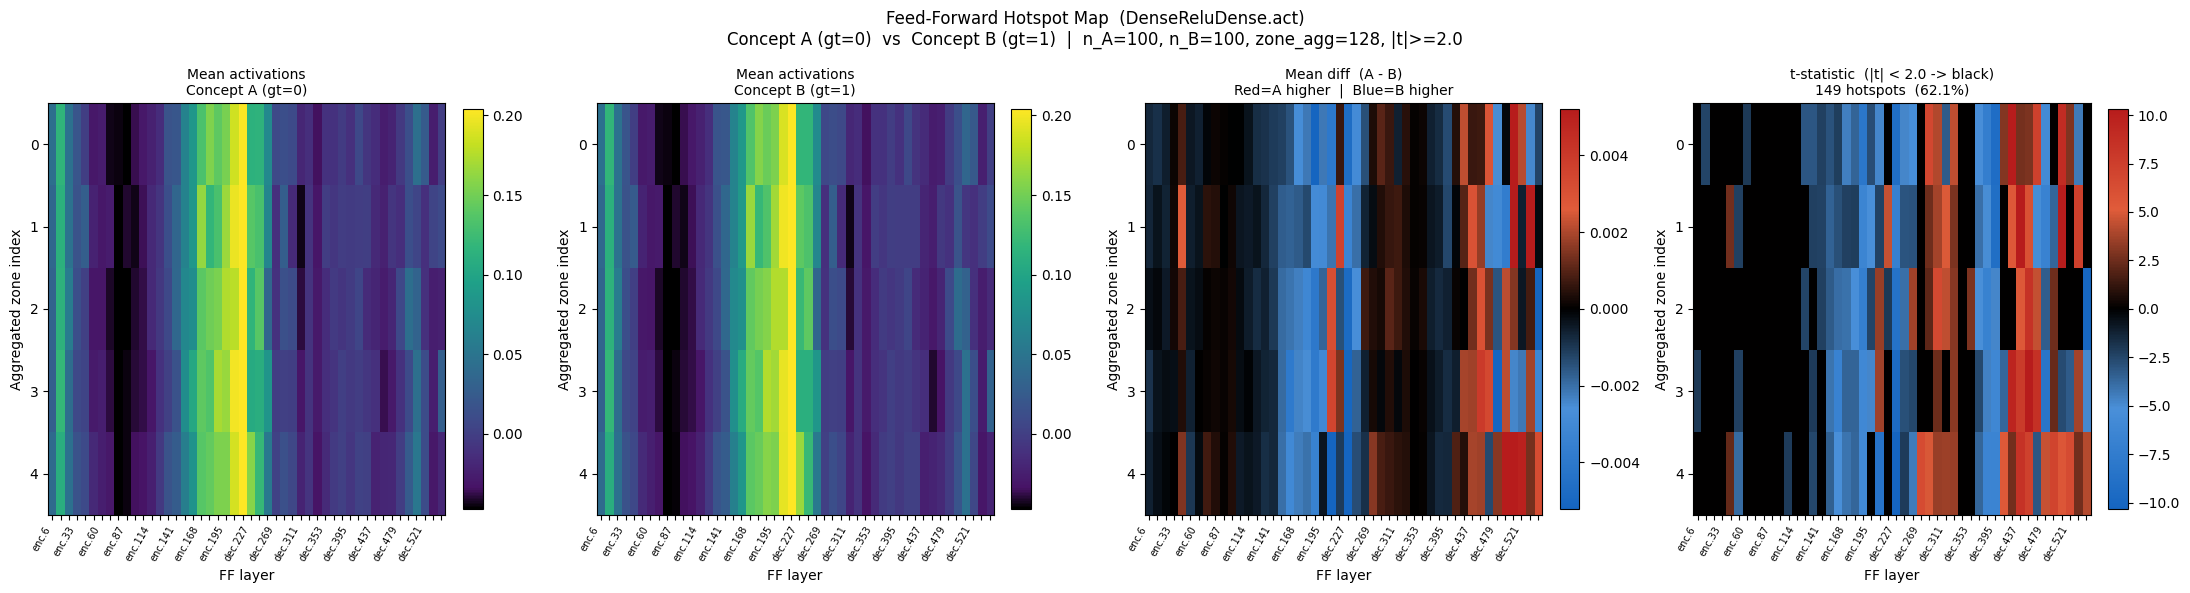

Saved -> hotspot_map.png


In [51]:
# Custom colormaps with black at zero / near-zero
# Mean panels: black (no activation) -> viridis bright (high activation)
black_viridis = mcolors.LinearSegmentedColormap.from_list(
    "black_viridis",
    [(0.0, "black")] + [(v, plt.cm.viridis(v)) for v in np.linspace(0.05, 1.0, 12)],
)
# Diff / t-stat panels: blue (B>A) -> black (no diff) -> red (A>B)
black_diverging = mcolors.LinearSegmentedColormap.from_list(
    "black_diverging",
    ["#1565c0", "#4a90d9", "black", "#e05c3a", "#b71c1c"],
)

fig, axes = plt.subplots(1, 4, figsize=(22, max(6, zone_size // 6)))
fig.suptitle(
    f"Feed-Forward Hotspot Map  ({LAYER_NAME_FILTER})\n"
    f"{LABEL_A}  vs  {LABEL_B}  |  "
    f"n_A={n_a}, n_B={n_b}, zone_agg={ZONE_AGGREGATE}, |t|>={T_THRESHOLD}",
    fontsize=12,
)

# Layers on x-axis: tick every N labels to avoid crowding
x_ticks  = np.arange(n_layers)
x_labels = [FF_LABELS[i] if i % max(1, n_layers // 16) == 0 else "" for i in range(n_layers)]


def apply_xticks(ax):
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=60, ha="right", fontsize=7)


def pct_clim(data, lo=2, hi=98):
    return float(np.percentile(data, lo)), float(np.percentile(data, hi))


# All imshow calls use transposed data so shape is (zone_size, n_layers)
# => layers on x-axis, zones on y-axis

# --- Panel 1: mean A ---
vmin, vmax = pct_clim(mean_a)
im0 = axes[0].imshow(mean_a.T, aspect="auto", cmap=black_viridis,
                     vmin=vmin, vmax=vmax, origin="upper")
axes[0].set_title(f"Mean activations\n{LABEL_A}", fontsize=10)
axes[0].set_xlabel("FF layer")
axes[0].set_ylabel("Aggregated zone index")
apply_xticks(axes[0])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- Panel 2: mean B (same colour scale as panel 1 for direct comparison) ---
im1 = axes[1].imshow(mean_b.T, aspect="auto", cmap=black_viridis,
                     vmin=vmin, vmax=vmax, origin="upper")
axes[1].set_title(f"Mean activations\n{LABEL_B}", fontsize=10)
axes[1].set_xlabel("FF layer")
axes[1].set_ylabel("Aggregated zone index")
apply_xticks(axes[1])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Panel 3: mean difference ---
diff_abs = max(abs(np.percentile(mean_diff, 2)), abs(np.percentile(mean_diff, 98))) or 1.0
norm_diff = mcolors.TwoSlopeNorm(vmin=-diff_abs, vcenter=0, vmax=diff_abs)
im2 = axes[2].imshow(mean_diff.T, aspect="auto", cmap=black_diverging,
                     norm=norm_diff, origin="upper")
axes[2].set_title("Mean diff  (A - B)\nRed=A higher  |  Blue=B higher", fontsize=10)
axes[2].set_xlabel("FF layer")
axes[2].set_ylabel("Aggregated zone index")
apply_xticks(axes[2])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# --- Panel 4: masked t-stat ---
t_display = np.where(sig_mask, t_stat, 0.0)   # 0 = black for non-significant
if sig_mask.any():
    t_abs = max(abs(np.percentile(t_display[sig_mask], 2)),
                abs(np.percentile(t_display[sig_mask], 98))) or 1.0
else:
    t_abs = 1.0
norm_t = mcolors.TwoSlopeNorm(vmin=-t_abs, vcenter=0, vmax=t_abs)
im3 = axes[3].imshow(t_display.T, aspect="auto", cmap=black_diverging,
                     norm=norm_t, origin="upper")
axes[3].set_title(
    f"t-statistic  (|t| < {T_THRESHOLD} -> black)\n"
    f"{sig_mask.sum()} hotspots  ({pct_sig:.1f}%)",
    fontsize=10,
)
axes[3].set_xlabel("FF layer")
axes[3].set_ylabel("Aggregated zone index")
apply_xticks(axes[3])
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("hotspot_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> hotspot_map.png")

## Cell 8 — Top-K hotspot coordinates

In [22]:
sig_coords = np.argwhere(sig_mask)
if len(sig_coords) == 0:
    print(f"No significant positions. Try lowering T_THRESHOLD (currently {T_THRESHOLD}).")
else:
    sig_t    = np.abs(t_stat[sig_mask])
    sig_diff = mean_diff[sig_mask]
    order    = np.argsort(-sig_t)

    print(f"{'Rank':<5} {'Layer':<12} {'Zone':<7} {'|t|':<8} {'mean_diff':<12} {'Direction'}")
    print("-" * 58)
    for rank, idx in enumerate(order[:TOP_K]):
        ly, zo = sig_coords[idx]
        layer_label = FF_LABELS[ly] if ly < len(FF_LABELS) else str(ly)
        direction   = "A > B" if sig_diff[idx] > 0 else "B > A"
        print(f"{rank+1:<5} {layer_label:<12} {zo:<7} {sig_t[idx]:<8.2f} {sig_diff[idx]:<12.4f} {direction}")

Rank  Layer        Zone    |t|      mean_diff    Direction
----------------------------------------------------------
1     dec.467      3       17.18    -1.0250      B > A
2     dec.509      49      16.54    -2.0899      B > A
3     dec.509      12      16.33    2.6539       A > B
4     dec.537      56      16.23    -1.8993      B > A
5     dec.467      22      16.02    -1.0274      B > A
6     dec.481      42      15.94    1.1262       A > B
7     dec.495      19      15.84    -2.1684      B > A
8     dec.523      22      15.74    -2.3177      B > A
9     dec.467      18      15.74    -0.6299      B > A
10    dec.523      31      15.72    2.0051       A > B
11    dec.453      43      15.72    -0.3371      B > A
12    dec.551      24      15.59    -2.8374      B > A
13    dec.537      21      15.56    -2.3549      B > A
14    dec.537      10      15.56    2.5273       A > B
15    dec.467      27      15.55    1.0517       A > B
16    dec.467      29      15.54    1.2483       A > B
17

## Cell 9 — Per-layer hotspot profile

Shows how many significant zones exist at each FF layer and the mean |t| per layer.
Peaks reveal which depth in the network best separates the two concepts.

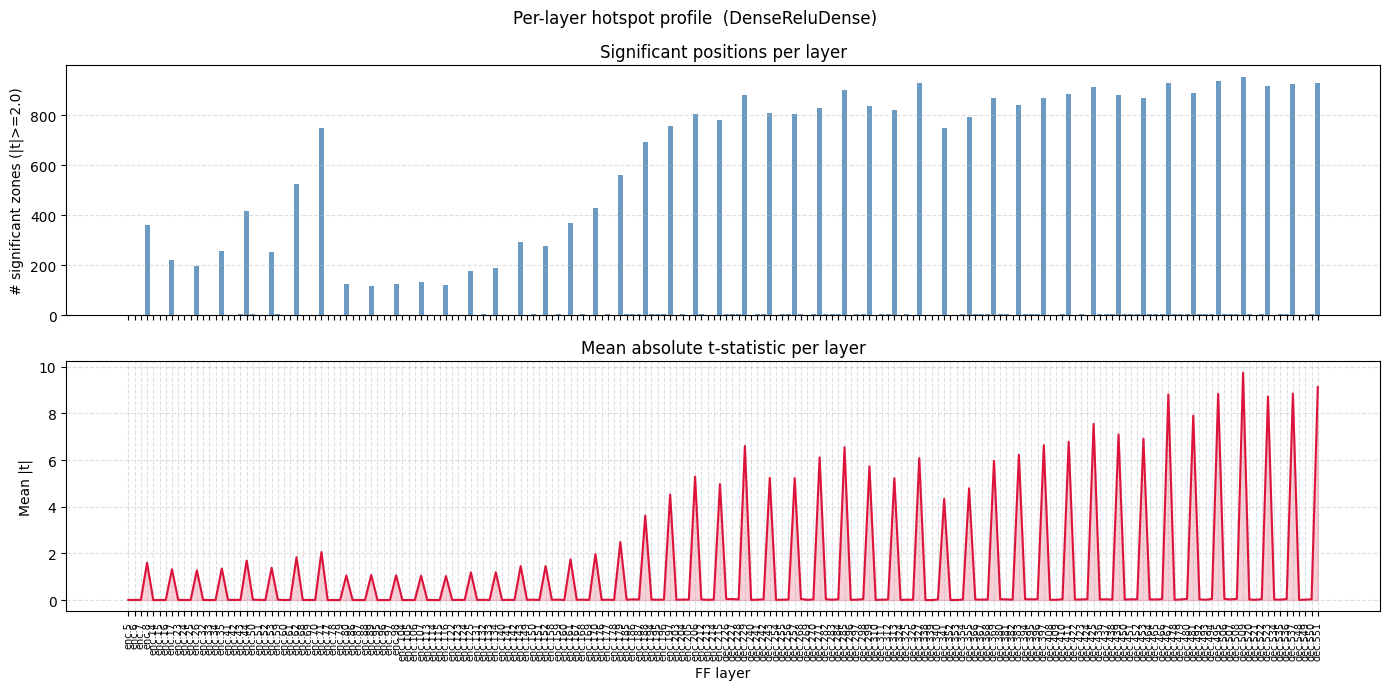

Top 10 FF layers by significant zone count:
Layer        Sig zones    Mean |t|
----------------------------------
dec.509      952          9.740
dec.495      935          8.832
dec.467      931          8.805
dec.327      930          6.081
dec.551      929          9.131
dec.537      926          8.844
dec.523      919          8.721
dec.425      914          7.546
dec.285      900          6.545
dec.481      890          7.897


In [16]:
n_sig_per_layer  = sig_mask.sum(axis=1)
mean_t_per_layer = np.abs(t_stat).mean(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f"Per-layer hotspot profile  ({LAYER_NAME_FILTER})", fontsize=12)

ax1.bar(range(n_layers), n_sig_per_layer, color="steelblue", alpha=0.8)
ax1.set_ylabel(f"# significant zones (|t|>={T_THRESHOLD})")
ax1.set_title("Significant positions per layer")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

ax2.plot(range(n_layers), mean_t_per_layer, color="crimson", linewidth=1.5)
ax2.fill_between(range(n_layers), mean_t_per_layer, alpha=0.2, color="crimson")
ax2.set_xticks(range(n_layers))
ax2.set_xticklabels(FF_LABELS, rotation=90, fontsize=7)
ax2.set_xlabel("FF layer")
ax2.set_ylabel("Mean |t|")
ax2.set_title("Mean absolute t-statistic per layer")
ax2.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("hotspot_layer_profile.png", dpi=150, bbox_inches="tight")
plt.show()

top_layers = np.argsort(-n_sig_per_layer)[:10]
print("Top 10 FF layers by significant zone count:")
print(f"{'Layer':<12} {'Sig zones':<12} {'Mean |t|'}")
print("-" * 34)
for li in top_layers:
    print(f"{FF_LABELS[li]:<12} {n_sig_per_layer[li]:<12} {mean_t_per_layer[li]:.3f}")